-------Attack Flag set-----------

Test Set Evaluation:
Accuracy: 0.9949
Precision: 0.9947
Recall: 0.9949
F1-Score: 0.9947


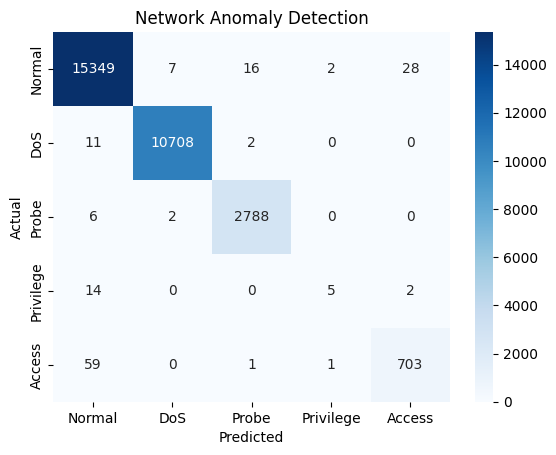

Classification Report for Test Set:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     15402
         DoS       1.00      1.00      1.00     10721
       Probe       0.99      1.00      1.00      2796
   Privilege       0.62      0.24      0.34        21
      Access       0.96      0.92      0.94       764

    accuracy                           0.99     29704
   macro avg       0.91      0.83      0.85     29704
weighted avg       0.99      0.99      0.99     29704

Model saved to network_anomaly_detection_model.joblib


In [9]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import joblib


# Set the file path to the dataset
file_path = r'KDD+.txt'

# Define the column names corresponding to the NSL-KDD dataset
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 
    'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 
    'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'attack', 'level'
]

data = pd.read_csv(file_path, names=columns)


# Binary classification target
# Maps normal traffic to 0 and any type of attack to 1
data['attack_flag'] = data['attack'].apply(lambda a: 0 if a == 'normal' else 1)

print ("-------Attack Flag set-----------")



# Multi-class classification target categories
dos_attacks = ['apache2', 'back', 'land', 'neptune', 'mailbomb', 'pod', 
               'processtable', 'smurf', 'teardrop', 'udpstorm', 'worm']
probe_attacks = ['ipsweep', 'mscan', 'nmap', 'portsweep', 'saint', 'satan']
privilege_attacks = ['buffer_overflow', 'loadmdoule', 'perl', 'ps', 
                     'rootkit', 'sqlattack', 'xterm']
access_attacks = ['ftp_write', 'guess_passwd', 'http_tunnel', 'imap', 
                  'multihop', 'named', 'phf', 'sendmail', 'snmpgetattack', 
                  'snmpguess', 'spy', 'warezclient', 'warezmaster', 
                  'xclock', 'xsnoop']

def map_attack(attack):
    if attack in dos_attacks:
        return 1
    elif attack in probe_attacks:
        return 2
    elif attack in privilege_attacks:
        return 3
    elif attack in access_attacks:
        return 4
    else:
        return 0

# Assign multi-class category to each row
data['attack_map'] = data['attack'].apply(map_attack)

# Encoding categorical variables
features_to_encode = ['protocol_type', 'service']
encoded = pd.get_dummies(data[features_to_encode])

# Numeric features that capture various statistical properties of the traffic
numeric_features = [
    'duration', 'src_bytes', 'dst_bytes', 'wrong_fragment', 'urgent', 'hot', 
    'num_failed_logins', 'num_compromised', 'root_shell', 'su_attempted', 
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 
    'num_outbound_cmds', 'count', 'srv_count', 'serror_rate', 
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 
    'dst_host_srv_rerror_rate'
]

# Combine encoded categorical variables and numeric features
train_set = encoded.join(data[numeric_features])

# Multi-class target variable
multi_y = data['attack_map']

# Split data into training and test sets for multi-class classification
train_X, test_X, train_y, test_y = train_test_split(train_set, multi_y, test_size=0.2, random_state=1337)

# Further split the training set into separate training and validation sets
multi_train_X, multi_val_X, multi_train_y, multi_val_y = train_test_split(train_X, train_y, test_size=0.3, random_state=1337)


# Train RandomForest model for multi-class classification
rf_model_multi = RandomForestClassifier(random_state=1337)
rf_model_multi.fit(multi_train_X, multi_train_y)

# Final evaluation on the test set
test_multi_predictions = rf_model_multi.predict(test_X)
test_accuracy = accuracy_score(test_y, test_multi_predictions)
test_precision = precision_score(test_y, test_multi_predictions, average='weighted')
test_recall = recall_score(test_y, test_multi_predictions, average='weighted')
test_f1 = f1_score(test_y, test_multi_predictions, average='weighted')
print("\nTest Set Evaluation:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# Confusion Matrix for Test Set
test_conf_matrix = confusion_matrix(test_y, test_multi_predictions)
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Network Anomaly Detection')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report for Test Set
print("Classification Report for Test Set:")
print(classification_report(test_y, test_multi_predictions, target_names=class_labels))

model_filename = 'network_anomaly_detection_model.joblib'
joblib.dump(rf_model_multi, model_filename)

print(f"Model saved to {model_filename}")



